# Code for comparing predictions vs Simulations

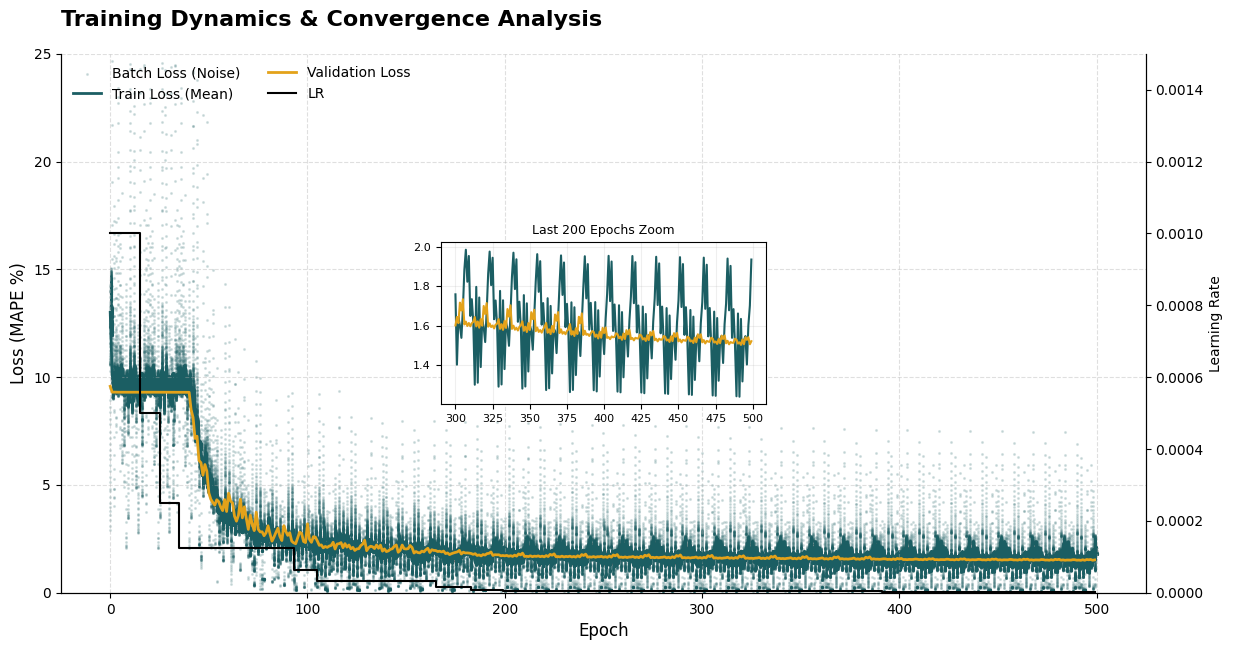

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import tikzplotlib
# 1. CARGA Y LIMPIEZA
df_epoch = pd.read_csv('./ckpts_final_1_bacth_logs_EarlyStopping16/loss_media_por_epoch.csv')
df_batch = pd.read_csv('./ckpts_final_1_bacth_logs_EarlyStopping16/loss_por_batch.csv')
df_epoch.columns = df_epoch.columns.str.strip()
df_batch.columns = df_batch.columns.str.strip()

# Eje X continuo para batches
batches_per_epoch = df_batch[df_batch['epoch'] == 0]['batch'].max() + 1
df_batch['epoch_continuous'] = df_batch['epoch'] + (df_batch['batch'] / batches_per_epoch)

# 2. CONFIGURACIÓN
servicecolors = ["#1b5e63", "#e3a21a", "#d64541", "#7cb342", "#6d4c41"]
plt.rcParams['axes.prop_cycle'] = cycler(color=servicecolors)
plt.rcParams['font.family'] = 'sans-serif'

fig, ax1 = plt.subplots(figsize=(14, 7), dpi=100)

# --- CAPA 1: BATCH LOSS (Puntos) ---
ax1.scatter(df_batch['epoch_continuous'], df_batch['loss_batch'], 
            color=servicecolors[0], s=1.5, alpha=0.15, label='Batch Loss (Noise)', zorder=1)

# --- CAPA 2: EPOCH LOSS (Líneas) ---
ax1.plot(df_epoch['epoch'], df_epoch['loss_media_train'], 
         color=servicecolors[0], linewidth=2, label='Train Loss (Mean)', zorder=3)

ax1.plot(df_epoch['epoch'], df_epoch['loss_val'], 
         color=servicecolors[1], linewidth=2, label='Validation Loss', zorder=4)

# --- CAPA 3: LEARNING RATE (Eje derecho) ---
ax2 = ax1.twinx()
ax2.step(df_epoch['epoch'], df_epoch['lr'], color='black', where='post', label='LR', zorder=2)
ax2.set_ylabel("Learning Rate", fontsize=10, color='black')
ax2.tick_params(axis='y', colors='black')
ax2.set_ylim(0, df_epoch['lr'].max() * 1.5)

# --- CAPA 4: ZOOM INSET (Mini-gráfica) ---
# Ubicación: 30% del tamaño, parte superior derecha
ax_ins = inset_axes(ax1, width="30%", height="30%", loc='center', borderpad=3)

# Datos del zoom (últimas 40 épocas)
tail_df = df_epoch.tail(200)
ax_ins.plot(tail_df['epoch'], tail_df['loss_media_train'], color=servicecolors[0], lw=1.5)
ax_ins.plot(tail_df['epoch'], tail_df['loss_val'], color=servicecolors[1], lw=1.5)

# Estilo del zoom
ax_ins.set_title("Last 200 Epochs Zoom", fontsize=9)
ax_ins.tick_params(labelsize=8)
ax_ins.grid(True, alpha=0.2)

# --- FINALIZACIÓN ---
ax1.set_title("Training Dynamics & Convergence Analysis", loc='left', fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Loss (MAPE %)", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.set_ylim(0, 25)

# Leyenda unificada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=False, ncol=2)

# Quitar bordes (spines) innecesarios para un look moderno
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

# plt.tight_layout()
# plt.show()
tikzplotlib.save("training_plot.tex", axis_height='10cm', axis_width='15cm')

In [2]:
import pandas as pd
import numpy as np

# 1. Asegurar que las columnas no tengan espacios y sean numéricas
df_batch.columns = df_batch.columns.str.strip()
df_batch['loss_batch'] = pd.to_numeric(df_batch['loss_batch'], errors='coerce')
df_batch['epoch'] = pd.to_numeric(df_batch['epoch'], errors='coerce')

# 2. Limpiar posibles valores NaN que rompen el cálculo de percentiles
df_batch = df_batch.dropna(subset=['loss_batch', 'epoch'])

# 3. Calcular percentiles 10 y 90 por época
# Usamos .quantile() que es más nativo de Pandas y más rápido
batch_stats = df_batch.groupby('epoch')['loss_batch'].quantile([0.1, 0.9]).unstack()

# 4. Renombrar columnas para que coincidan con el código LaTeX
batch_stats.columns = ['p10', 'p90']
batch_stats = batch_stats.reset_index()

# 5. Guardar el CSV
batch_stats.to_csv('batch_shadow.csv', index=False)

print("✅ Archivo 'batch_shadow.csv' generado correctamente.")
print(batch_stats.head()) # Para que verifiques los valores

✅ Archivo 'batch_shadow.csv' generado correctamente.
   epoch        p10        p90
0      0  11.090438  14.165918
1      1   9.333809   9.891673
2      2   9.360462  10.050080
3      3   9.232000   9.850851
4      4   9.242715   9.896479


In [3]:
# 1. Preparación de los nombres de columnas (limpieza)
df_epoch.columns = df_epoch.columns.str.strip()
df_batch.columns = df_batch.columns.str.strip()

# 2. Cálculo de la época continua para el eje X de los batches
batches_per_epoch = df_batch[df_batch['epoch'] == 0]['batch'].max() + 1
df_batch['epoch_continuous'] = df_batch['epoch'] + (df_batch['batch'] / batches_per_epoch)

# --- EXPORTACIÓN DE PUNTOS PARA TIKZ ---

# Tomamos 1 de cada 5 puntos (reduce el uso de memoria en un 80%)
# Visualmente el efecto de "nube" se mantiene idéntico
df_batch[['epoch_continuous', 'loss_batch']].iloc[::100].to_csv('batch_loss.csv', index=False)

# B. Epoch Loss (Train, Val y Learning Rate)
df_epoch[['epoch', 'loss_media_train', 'loss_val', 'lr']].to_csv('epoch_loss.csv', index=False)

# C. Zoom Loss (Últimas 200 épocas)
df_epoch.tail(200)[['epoch', 'loss_media_train', 'loss_val']].to_csv('zoom_loss.csv', index=False)

print("Archivos CSV generados con éxito para LaTeX:")
print("- batch_loss.csv")
print("- epoch_loss.csv")
print("- zoom_loss.csv")
# Percentiles 10 y 90 por época para el sombreado
batch_stats = df_batch.groupby('epoch')['loss_batch'].agg(
    p10=lambda x: np.percentile(x, 10),
    p90=lambda x: np.percentile(x, 90)
).reset_index()
batch_stats.to_csv('batch_shadow.csv', index=False)

Archivos CSV generados con éxito para LaTeX:
- batch_loss.csv
- epoch_loss.csv
- zoom_loss.csv


In [1]:
# -----------------------------
# Configuración
# -----------------------------
LEARNING_RATE = 0.001
TRAIN_PATH = "../final_set_dataset/oran-hqos_BW40_SCS30/train"
TEST_PATH = "../final_set_dataset/oran-hqos_BW40_SCS30/test"  # evaluamos sobre el mismo dataset para ver si memorizó
CKPT_DIR = "./ckpts_final_1_bacth_logs_EarlyStopping16/"
ZSCORE_PATH = "../final_set_dataset/oran-hqos_BW40_SCS30/zscore_stats2.json"

# -----------------------------

In [2]:

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import re
import numpy as np
import json
import tensorflow as tf
import matplotlib.pyplot as plt
servicecolors = [
    "#1b5e63",  
    "#e3a21a", 
    "#d64541",  
    "#7cb342",  
    "#6d4c41"  
]
from cycler import cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=servicecolors)
from data_generatorHQoS import input_fn
import sys
sys.path.append('../')
from delay_model_HQoS import RouteNet_Fermi

from sklearn.metrics import mean_absolute_error, mean_squared_error

def compute_normalization_stats(data_dirs: list):
    features_to_normalize = [
        'traffic', 'packets', 'eq_lambda', 'avg_pkts_lambda', 'exp_max_factor',
        'pkts_lambda_on', 'avg_t_off', 'avg_t_on', 'ar_a', 'sigma',
        'capacity', 'queue_size'
    ]
    stats = {feat: [] for feat in features_to_normalize}
    
    for data_dir in data_dirs:
        print(f"[*] Analizando datos en: {data_dir}")
        ds = input_fn(data_dir, shuffle=False)
        for inputs, _ in ds:
            for feat in features_to_normalize:
                if feat in inputs:
                    values = inputs[feat].numpy().flatten()
                    stats[feat].extend(values.tolist())
    
    z_score = {}
    for feat in features_to_normalize:
        if stats[feat]:
            mean_val = float(np.mean(stats[feat]))
            std_val = float(np.std(stats[feat]))
            
            # --- MEJORA: Si la desviación es 0, forzamos a 1 ---
            if std_val == 0:
                print(f" [!] Aviso: {feat} tiene desviación 0. Forzando a 1.0.")
                std_val = 1.0
            
            z_score[feat] = [mean_val, std_val]
        else:
            # Caso por defecto si no hay datos para esa feature
            z_score[feat] = [0.0, 1.0]
            
    return z_score


def update_model_z_score(model, z_score_dict):
    if not hasattr(model, 'z_score') or model.z_score is None:
        model.z_score = {}
    updates = {k: v for k, v in z_score_dict.items() if isinstance(v, list) and v[1] != 0}
    model.z_score.update(updates)
    print(f"✓ Z-Score actualizado para {len(updates)} campos.")



✓ Z-Score actualizado para 12 campos.
[*] Z-Score cargado y aplicado al modelo.
Mejor checkpoint encontrado: epoch_493_loss_1.5022
1408/1408 [==============================] - 26s 12ms/step
MAE: 0.000001
RMSE: 0.000003
MRE (%): 1.55%


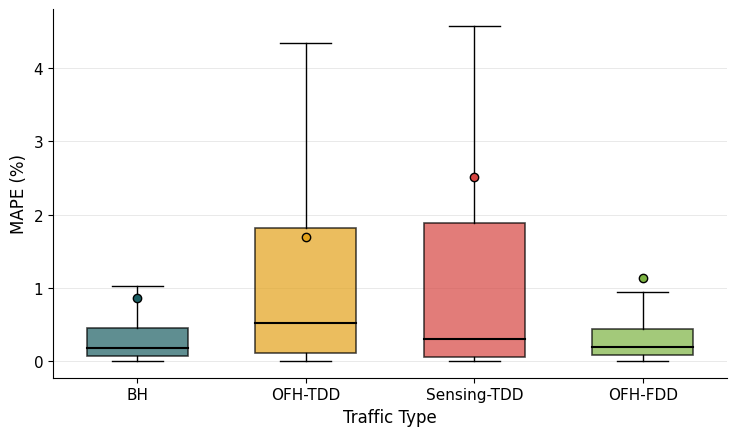

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import re
import os
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -----------------------------
# 1. Configuración del Modelo y Carga
# -----------------------------
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
loss_object = tf.keras.losses.MeanAbsolutePercentageError()
model = RouteNet_Fermi()

zscore_path = ZSCORE_PATH
if zscore_path and os.path.exists(zscore_path):
    with open(zscore_path, 'r') as f:
        loaded_z_score = json.load(f)
    update_model_z_score(model, loaded_z_score)
    print("[*] Z-Score cargado y aplicado al modelo.")
else:
    print("[!] No se encontró Z-Score. Calculando...")
    z_score_stats = compute_normalization_stats([TRAIN_PATH, TEST_PATH])
    update_model_z_score(model, z_score_stats)
    with open(zscore_path, 'w') as f:
        json.dump(z_score_stats, f, indent=4)

model.compile(loss=loss_object, optimizer=optimizer, run_eagerly=False)

# Buscar mejor checkpoint
best = None
best_mre = float('inf')
for f in os.listdir(CKPT_DIR):
    if f.endswith(".index"):
        reg = re.findall(r"\d+\.\d+", f)
        if len(reg) > 0:
            mre = float(reg[0])
            if mre <= best_mre:
                best = f.replace('.index','')
                best_mre = mre

print(f"Mejor checkpoint encontrado: {best}")
model.load_weights(os.path.join(CKPT_DIR, best)).expect_partial()

# -----------------------------
# 2. Inferencia y Métricas
# -----------------------------
ds_test = input_fn(TEST_PATH, shuffle=False)
predictions = model.predict(ds_test, verbose=1).flatten()

real_delays = []
flow_names = []

# Extraer etiquetas reales y asignar nombres de flujos (ajusta según tu dataset)
for x, y in ds_test:
    y_val = y.numpy().flatten()
    real_delays.extend(y_val)
    # Aquí asignamos nombres según el índice del flujo en el batch
    for idx in range(len(y_val)):
        flow_names.append(f"f_{idx}")

real_delays = np.array(real_delays)
flow_names = np.array(flow_names)
errors = np.abs((real_delays - predictions) / real_delays) * 100

print(f"MAE: {mean_absolute_error(real_delays, predictions):.6f}")
print(f"RMSE: {np.sqrt(mean_squared_error(real_delays, predictions)):.6f}")
print(f"MRE (%): {np.mean(errors):.2f}%")

# -----------------------------
# 3. Gráfico Estilo "Paper"
# -----------------------------

# Estilo Global
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "CMU Sans Serif", "DejaVu Sans"],
    "mathtext.fontset": "cm",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

unique_flows = np.unique(flow_names)
data_to_plot = [errors[flow_names == f] for f in unique_flows]


fig, ax = plt.subplots(figsize=(7.5, 4.5))

box = ax.boxplot(
    data_to_plot,
    labels=unique_flows,
    patch_artist=True,
    showmeans=True,
    meanline=False,   
    showfliers=False,
    widths=0.6
)

# Estética de las cajas
for i, patch in enumerate(box['boxes']):
    color = servicecolors[i % len(servicecolors)]
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_edgecolor("black")
    patch.set_linewidth(1.2)

# Medianas y Medias
for median in box['medians']:
    median.set(color='black', linewidth=1.5)

for i, mean in enumerate(box['means']):
    color = servicecolors[i % len(servicecolors)]
    mean.set(marker='o', markerfacecolor=color, markeredgecolor="black", markersize=6, linestyle='none')

# Bigotes y Caps
for whisker in box['whiskers']:
    whisker.set(color='black', linewidth=1)
for cap in box['caps']:
    cap.set(color='black', linewidth=1)

# Refinamiento de Ejes
ax.grid(axis='y', linestyle='-', linewidth=0.5, alpha=0.4)
ax.set_axisbelow(True)
ax.set_ylabel("MAPE (%)")
ax.set_xlabel("Traffic Type")

# IMPORTANTE: Ajusta estos nombres según el orden de tus flujos reales
# Si tienes 4 tipos de tráfico:
if len(unique_flows) == 4:
    ax.set_xticklabels(["BH", "OFH-TDD", "Sensing-TDD", "OFH-FDD"])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


--- GLOBAL METRICS (Scaled to µs) ---
Global MAPE: 0.767% | Global MAE: 0.320 µs | Global RMSE: 2.193 µs | Global R^2: 0.9604

--- METRICS BY TRAFFIC TYPE ---
Traffic Type  MAPE  MAE (µs)  RMSE (µs)     R2
          BH 0.634     0.198      1.056 0.9880
     OFH-TDD 0.467     0.181      1.476 0.9808
 Sensing-TDD 1.314     0.584      3.023 0.9317
     OFH-FDD 0.653     0.316      2.610 0.9499
Archivo 'metrics.csv' generado con éxito.

--- GLOBAL METRICS (Scaled to µs) ---
Global MAPE: 0.767% | Global MAE: 0.320 µs | Global RMSE: 2.193 µs | Global R^2: 0.9604

--- METRICS BY TRAFFIC TYPE ---
Traffic Type  MAPE  MAE (µs)  RMSE (µs)     R2
          BH 0.634     0.198      1.056 0.9880
     OFH-TDD 0.467     0.181      1.476 0.9808
 Sensing-TDD 1.314     0.584      3.023 0.9317
     OFH-FDD 0.653     0.316      2.610 0.9499


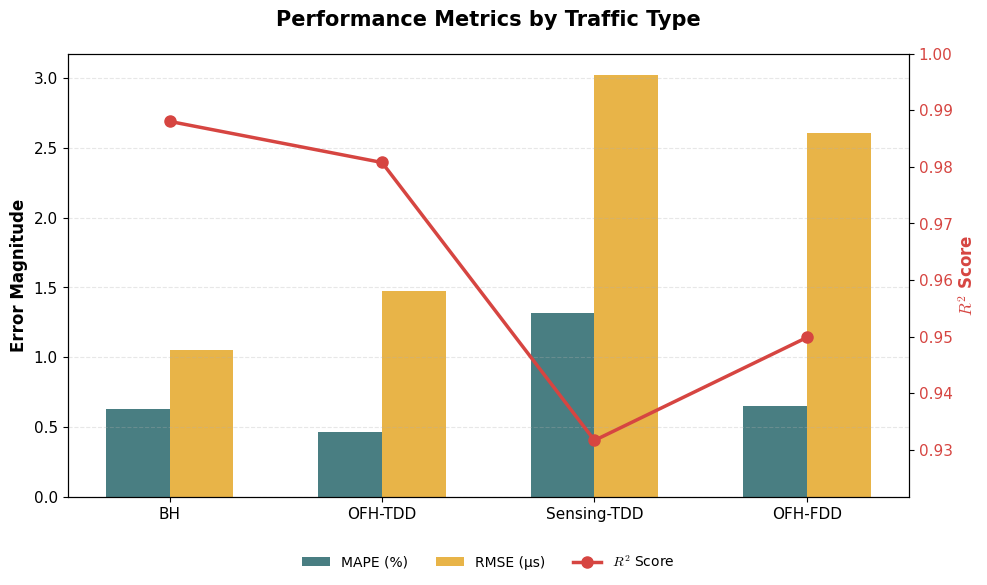

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. CONFIGURACIÓN Y CÁLCULO DE MÉTRICAS ---
SCALE = 1e6  # Segundos a Microsegundos

# Métricas globales
mae_val = mean_absolute_error(real_delays, predictions) * SCALE
rmse_val = np.sqrt(mean_squared_error(real_delays, predictions)) * SCALE
r2_val = r2_score(real_delays, predictions)
mape_val = np.mean(np.abs((real_delays - predictions) / np.maximum(real_delays, 1e-9))) * 100

traffic_metrics = []
name_map = {"f_0": "BH", "f_1": "OFH-TDD", "f_2": "Sensing-TDD", "f_3": "OFH-FDD"}

# Listas auxiliares para la gráfica
labels = []
mape_list = []
rmse_list = []
r2_list = []

for flow_type in unique_flows:
    mask = (flow_names == flow_type)
    y_true = real_delays[mask]
    y_pred = predictions[mask]
    
    m_mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-9))) * 100
    m_mae = mean_absolute_error(y_true, y_pred) * SCALE
    m_rmse = np.sqrt(mean_squared_error(y_true, y_pred)) * SCALE
    m_r2 = r2_score(y_true, y_pred)
    
    # Nombre legible
    t_name = name_map.get(flow_type, flow_type)
    
    # Guardar para DataFrame
    traffic_metrics.append({
        "Traffic Type": t_name,
        "MAPE": round(m_mape, 3),
        "MAE (µs)": round(m_mae, 3),
        "RMSE (µs)": round(m_rmse, 3),
        "R2": round(m_r2, 4)
    })
    
    # Guardar para Gráfica
    labels.append(t_name)
    mape_list.append(m_mape)
    rmse_list.append(m_rmse)
    r2_list.append(m_r2)

# --- 2. IMPRESIÓN DE RESULTADOS (TABLA) ---
df_metrics = pd.DataFrame(traffic_metrics)

print("\n--- GLOBAL METRICS (Scaled to µs) ---")
print(f"Global MAPE: {mape_val:.3f}% | Global MAE: {mae_val:.3f} µs | Global RMSE: {rmse_val:.3f} µs | Global R^2: {r2_val:.4f}")
print("\n--- METRICS BY TRAFFIC TYPE ---")
print(df_metrics.to_string(index=False))

df_metrics.to_csv('metrics.csv', index=False)

print(f"Archivo 'metrics.csv' generado con éxito.")
print("\n--- GLOBAL METRICS (Scaled to µs) ---")
print(f"Global MAPE: {mape_val:.3f}% | Global MAE: {mae_val:.3f} µs | Global RMSE: {rmse_val:.3f} µs | Global R^2: {r2_val:.4f}")
print("\n--- METRICS BY TRAFFIC TYPE ---")
print(df_metrics.to_string(index=False))

# --- 3. GENERACIÓN DE LA GRÁFICA ---
x = np.arange(len(labels))
width = 0.3

fig, ax1 = plt.subplots(figsize=(10, 6))

# Barras de Error (MAPE y RMSE)
bar_mape = ax1.bar(x - width/2, mape_list, width, label='MAPE (%)', color='#1b5e63', alpha=0.8)
bar_rmse = ax1.bar(x + width/2, rmse_list, width, label='RMSE (µs)', color='#e3a21a', alpha=0.8)

ax1.set_ylabel('Error Magnitude', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=11)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Línea de R^2 en eje secundario
ax2 = ax1.twinx()
line_r2 = ax2.plot(x, r2_list, color='#d64541', marker='o', linewidth=2.5, markersize=8, label='$R^2$ Score')
ax2.set_ylabel('$R^2$ Score', fontsize=12, color='#d64541', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#d64541')
ax2.set_ylim(min(r2_list) - 0.01, 1.0) # Zoom dinámico según resultados

# Unificar leyendas
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False)

plt.title('Performance Metrics by Traffic Type', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

/home/administrator/6gsenses/venv/lib/python3.7/site-packages/ipykernel_launcher.py:76: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.


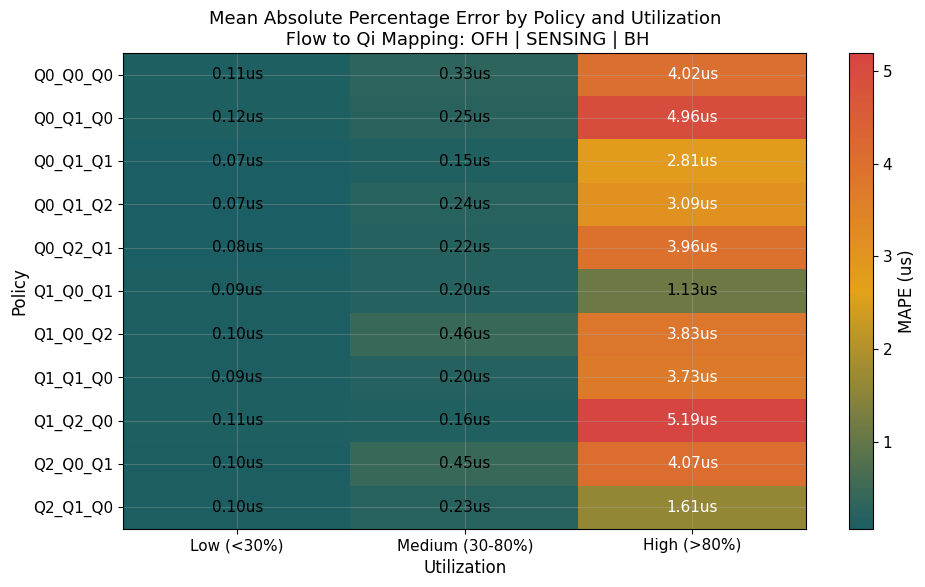

In [8]:
import tarfile
import io
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from cycler import cycler
from data_generatorHQoS import input_fn
# --- TU ESTILO DE COLORES ---
servicecolors = [
    "#1b5e63",  # Petróleo/Verde oscuro
    "#e3a21a",  # Ámbar/Dorado
    "#d64541",  # Carmín/Rojo
    "#7cb342",  # Manzana/Verde
    "#6d4c41"   # Marrón/Tierra
]
plt.rcParams['axes.prop_cycle'] = cycler(color=servicecolors)
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.grid'] = True

# --- CONFIGURACIÓN DE RUTAS ---
BASE_PATH = Path("/home/administrator/6gsenses/RouteNet-Fermi/final_set_dataset/oran-hqos_BW40_SCS30/test")
TAR_FILE = BASE_PATH / "batch_0000.tar.gz"

# 1. LEER DESCRIPTOR DESDE EL TAR
with tarfile.open(TAR_FILE, "r:gz") as tar:
    member = [m for m in tar.getmembers() if "descriptor.txt" in m.name][0]
    f = tar.extractfile(member)
    desc_df = pd.read_csv(io.BytesIO(f.read()), sep=';', header=None, names=['idx', 'scenario_full'])

def get_policy(s):
    m = re.search(r"(Q\d+_Q\d+_Q\d+)", s)
    return m.group(1) if m else "UNK"

def get_utilization_cat(s):
    m = re.search(r"UTIL(\d+\.\d+)", s)
    if m:
        val = float(m.group(1))
        if val < 30: return "Low (<30%)"
        elif val < 80: return "Medium (30-80%)"
        else: return "High (>80%)"
    return "Unknown"

# 2. PROCESAR DATOS
rows = []
cursor = 0
for i, (_, y) in enumerate(input_fn(str(BASE_PATH), shuffle=False)):
    y_real = y.numpy().flatten()
    y_pred = predictions[cursor:cursor + len(y_real)]
    scen_full = desc_df.iloc[i]['scenario_full'] if i < len(desc_df) else "unknown"
    
    pol = get_policy(scen_full)
    util_cat = get_utilization_cat(scen_full)

    for r, p in zip(y_real, y_pred):
        rows.append({
            "scenario": scen_full, "policy": pol, "utilization": util_cat,
            "real": r * 1e6, "pred": p * 1e6,
            "err": abs(r - p) * 1e6, "perc_err": (abs(r - p) / r * 100) if r != 0 else 0
        })
    cursor += len(y_real)

df = pd.DataFrame(rows)

# --- GRÁFICA 1: HEATMAP (Usando una variante de tus colores para el degradado) ---
pivot = df.groupby(["policy", "utilization"])["perc_err"].mean().unstack()
cols_order = [c for c in ["Low (<30%)", "Medium (30-80%)", "High (>80%)"] if c in pivot.columns]
pivot = pivot[cols_order]

plt.figure(figsize=(10, 6))
from matplotlib.colors import LinearSegmentedColormap
my_cmap = LinearSegmentedColormap.from_list("service_map", [servicecolors[0], servicecolors[1], servicecolors[2]])

im = plt.imshow(pivot, aspect="auto", cmap=my_cmap)
plt.colorbar(im, label="MAPE (us)")

plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.iloc[i, j]
        plt.text(j, i, f"{val:.2f}us", ha="center", va="center", color="white" if val > pivot.values.mean() else "black")

plt.xlabel("Utilization")
plt.ylabel("Policy")

# Título con categoría incluida
plt.title("Mean Absolute Percentage Error by Policy and Utilization\n Flow to Qi Mapping: OFH | SENSING | BH")
plt.tight_layout()

# # --- GRÁFICA 2: COMPARATIVA (USANDO TU CYCLER) ---
# # Aquí, 'Real' usará el primer color (#1b5e63) y 'Pred' el segundo (#e3a21a)
# for util in cols_order:
#     sub = df[df["utilization"] == util].groupby("scenario")[["real", "pred"]].mean().reset_index()
#     if sub.empty: continue
    
#     plt.figure(figsize=(14, 7))
#     plt.plot(sub.index, sub["real"], label="Real", linewidth=1.5, marker='o', markersize=4)
#     plt.plot(sub.index, sub["pred"], label="Pred", linewidth=1.5, marker='x', markersize=4)
    
#     plt.title(f"Delay Mean - Carga: {util}")
#     plt.ylabel("Delay (us)")
#     plt.xlabel("Escenarios")
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

/home/administrator/6gsenses/venv/lib/python3.7/site-packages/ipykernel_launcher.py:70: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.


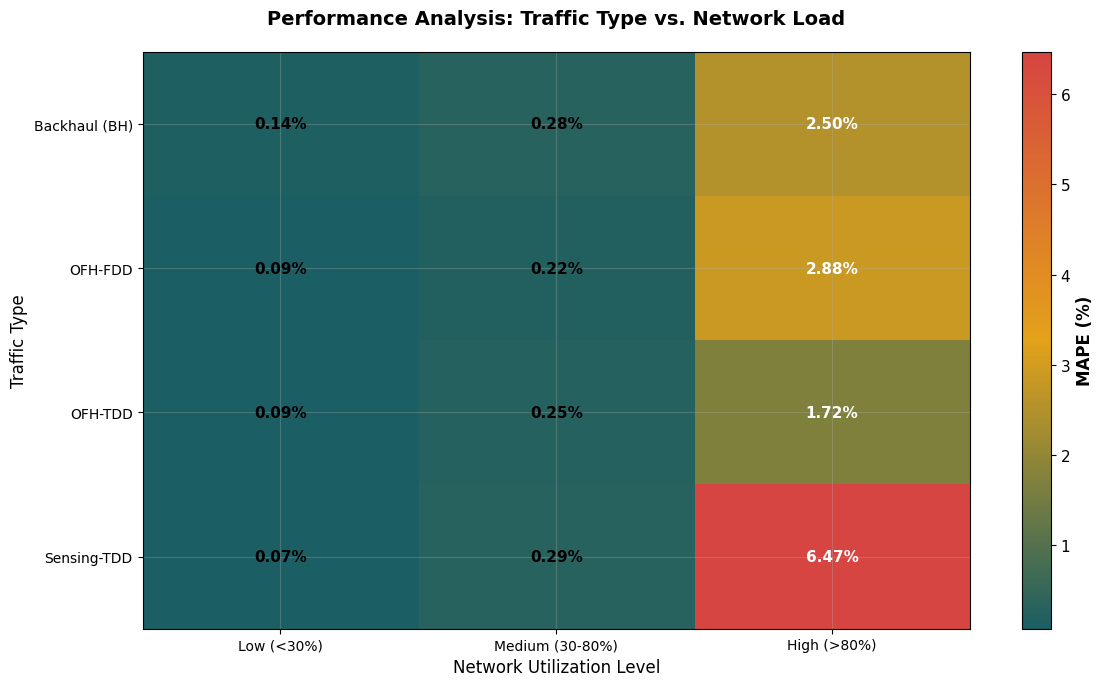

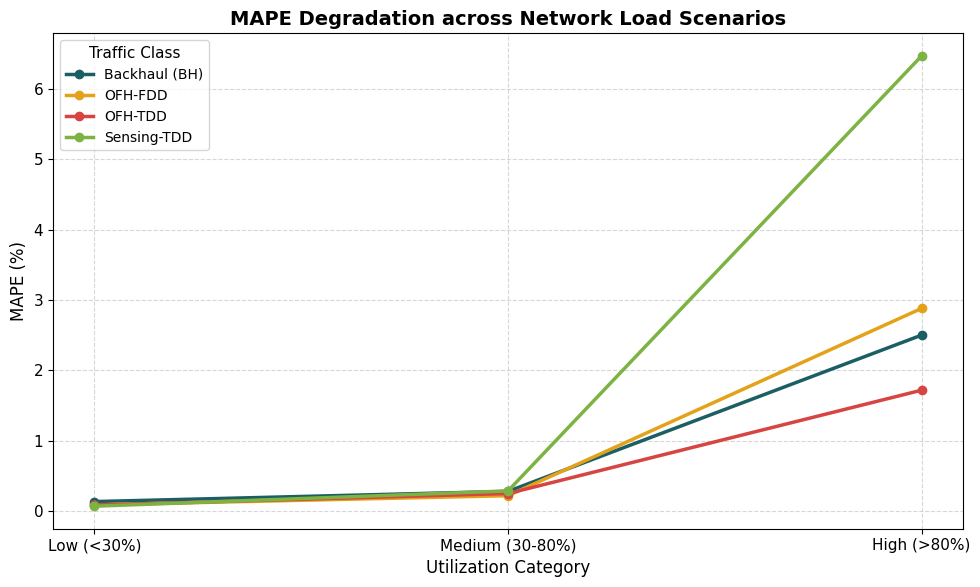

In [9]:
import tarfile
import io
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from cycler import cycler
from sklearn.metrics import r2_score
from matplotlib.colors import LinearSegmentedColormap

# --- CONFIGURACIÓN DE ESTILO ---
servicecolors = ["#1b5e63", "#e3a21a", "#d64541", "#7cb342"]
plt.rcParams['axes.prop_cycle'] = cycler(color=servicecolors)

# --- 1. PROCESAMIENTO CON DIMENSIÓN DE FLUJO ---
rows = []
cursor = 0

# Mapeo de nombres de flujos (asumiendo f_0=BH, f_1=OFH, f_2=Sensing)
flow_name_map = {0: "Backhaul (BH)", 1: "OFH-TDD", 2: "Sensing-TDD", 3: "OFH-FDD"}

for i, (_, y) in enumerate(input_fn(str(BASE_PATH), shuffle=False)):
    y_real = y.numpy().flatten()
    y_pred = predictions[cursor:cursor + len(y_real)]
    scen_full = desc_df.iloc[i]['scenario_full'] if i < len(desc_df) else "unknown"
    
    util_cat = get_utilization_cat(scen_full)
    pol = get_policy(scen_full)

    # El índice j representa el tipo de flujo dentro de este escenario
    for j, (r, p) in enumerate(zip(y_real, y_pred)):
        rows.append({
            "utilization": util_cat,
            "flow_type": flow_name_map.get(j, f"Flow_{j}"),
            "real": r * 1e6,
            "pred": p * 1e6,
            "perc_err": (abs(r - p) / r * 100) if r != 0 else 0
        })
    cursor += len(y_real)

df_analysis = pd.DataFrame(rows)

# --- 2. CÁLCULO DE MÉTRICAS AGRUPADAS (FLUJO Y CARGA) ---
# Orden lógico para la carga
u_order = ["Low (<30%)", "Medium (30-80%)", "High (>80%)"]

# Agrupamos para obtener MAPE y R2 por cada par (Flujo, Carga)
stats_list = []
for (flow, util), group in df_analysis.groupby(["flow_type", "utilization"]):
    mape = group["perc_err"].mean()
    r2 = r2_score(group["real"], group["pred"])
    stats_list.append({
        "Traffic Type": flow,
        "Utilization": util,
        "MAPE (%)": mape,
        "R2": r2
    })

df_stats = pd.DataFrame(stats_list)

# --- 3. VISUALIZACIÓN: MATRIX HEATMAP (FLUJO vs UTILIZACIÓN) ---
pivot_mape = df_stats.pivot(index="Traffic Type", columns="Utilization", values="MAPE (%)")
pivot_mape = pivot_mape[u_order] # Reordenar columnas

plt.figure(figsize=(12, 7))
my_cmap = LinearSegmentedColormap.from_list("paper_map", [servicecolors[0], servicecolors[1], servicecolors[2]])

im = plt.imshow(pivot_mape, aspect="auto", cmap=my_cmap)
cbar = plt.colorbar(im)
cbar.set_label('MAPE (%)', fontweight='bold')

plt.xticks(range(len(pivot_mape.columns)), pivot_mape.columns, fontsize=10)
plt.yticks(range(len(pivot_mape.index)), pivot_mape.index, fontsize=10)

# Añadir etiquetas de texto
for i in range(pivot_mape.shape[0]):
    for j in range(pivot_mape.shape[1]):
        val = pivot_mape.iloc[i, j]
        plt.text(j, i, f"{val:.2f}%", ha="center", va="center", 
                 color="white" if val > pivot_mape.values.mean() else "black",
                 fontweight='bold')

plt.title("Performance Analysis: Traffic Type vs. Network Load", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Network Utilization Level", fontsize=12)
plt.ylabel("Traffic Type", fontsize=12)
plt.tight_layout()
plt.show()

# --- 4. GRÁFICA DE LÍNEAS: DEGRADACIÓN POR CARGA ---
plt.figure(figsize=(10, 6))
for i, flow in enumerate(df_stats["Traffic Type"].unique()):
    subset = df_stats[df_stats["Traffic Type"] == flow]
    # Asegurar orden para la línea
    subset = subset.set_index("Utilization").reindex(u_order).reset_index()
    plt.plot(subset["Utilization"], subset["MAPE (%)"], marker='o', linewidth=2.5, label=flow)

plt.title("MAPE Degradation across Network Load Scenarios", fontsize=14, fontweight='bold')
plt.ylabel("MAPE (%)", fontsize=12)
plt.xlabel("Utilization Category", fontsize=12)
plt.legend(title="Traffic Class")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

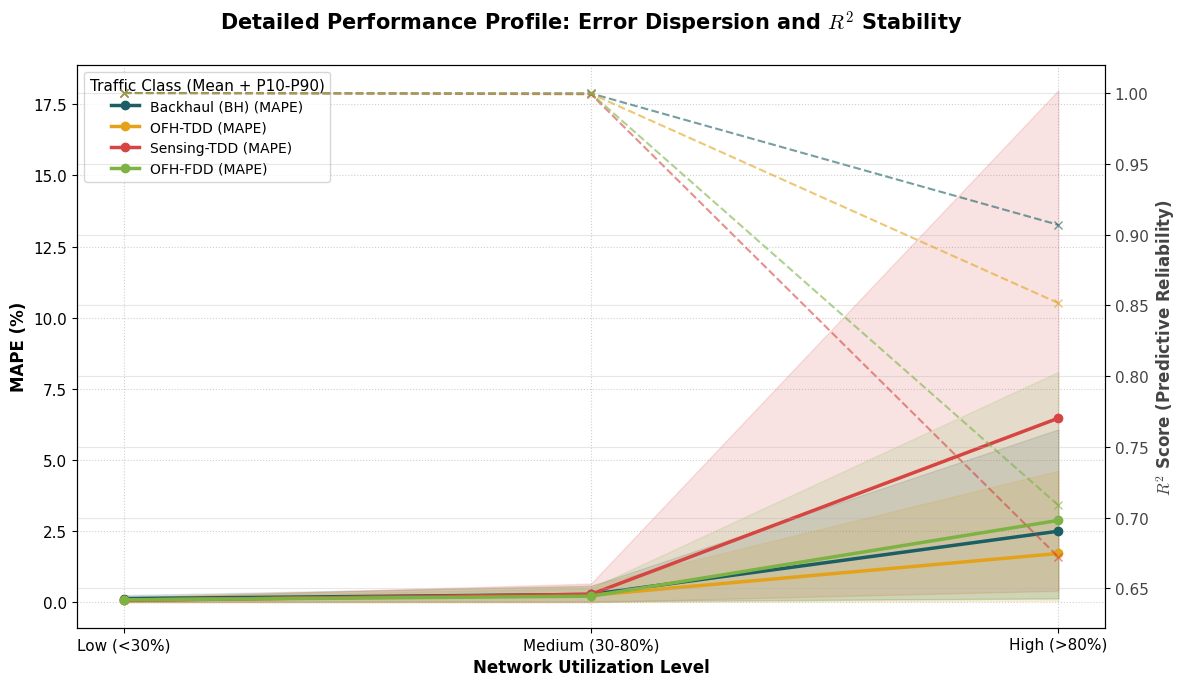

In [10]:
# --- 4. GRÁFICA DE LÍNEAS AVANZADA: MAPE (Media + Percentiles) & R2 ---
fig, ax1 = plt.subplots(figsize=(12, 7))

# Segundo eje para el R2
ax2 = ax1.twinx()

# Asegurar que el orden de utilización es el correcto
u_order = ["Low (<30%)", "Medium (30-80%)", "High (>80%)"]

for i, flow in enumerate(df_analysis["flow_type"].unique()):
    # 1. Extraer datos crudos para percentiles
    subset_raw = df_analysis[df_analysis["flow_type"] == flow]
    
    # 2. Calcular media y percentiles por categoría de carga
    summary = subset_raw.groupby("utilization")["perc_err"].agg(
        mean='mean',
        p10=lambda x: np.percentile(x, 10),
        p90=lambda x: np.percentile(x, 90)
    ).reindex(u_order)
    
    # 3. Extraer R2 del dataframe de estadísticas (df_stats)
    r2_data = df_stats[df_stats["Traffic Type"] == flow].set_index("Utilization").reindex(u_order)

    color = servicecolors[i % len(servicecolors)]
    
    # --- EJE IZQUIERDO: MAPE Y ÁREA DE CONFIANZA ---
    # Línea de la media
    ax1.plot(u_order, summary["mean"], marker='o', linewidth=2.5, 
             label=f"{flow} (MAPE)", color=color, zorder=3)
    
    # Sombreado entre percentil 10 y 90 (Variabilidad del error)
    ax1.fill_between(u_order, summary["p10"], summary["p90"], 
                     color=color, alpha=0.15, zorder=2)

    # --- EJE DERECHO: R2 SCORE ---
    # Línea discontinua con marcadores 'x'
    ax2.plot(u_order, r2_data["R2"], marker='x', linestyle='--', 
             linewidth=1.5, alpha=0.6, label=f"{flow} ($R^2$)", color=color, zorder=1)

# --- ESTÉTICA Y REFINAMIENTO ---
ax1.set_xlabel("Network Utilization Level", fontsize=12, fontweight='bold')
ax1.set_ylabel("MAPE (%)", fontsize=12, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)

# Configuración del eje R2
ax2.set_ylabel("$R^2$ Score (Predictive Reliability)", fontsize=12, fontweight='bold', color="#444444")
ax2.set_ylim(min(df_stats["R2"]) - 0.05, 1.02) # Zoom dinámico al rango de R2
ax2.tick_params(axis='y', labelcolor='#444444')

# Título profesional
plt.title("Detailed Performance Profile: Error Dispersion and $R^2$ Stability", 
          fontsize=15, fontweight='bold', pad=25)

# Leyenda unificada
lines_1, labels_1 = ax1.get_legend_handles_labels()
# Opcional: solo mostramos el MAPE en leyenda para no saturar, o ambos
ax1.legend(lines_1, labels_1, title="Traffic Class (Mean + P10-P90)", 
           loc='upper left', frameon=True, fontsize=10)

plt.tight_layout()
plt.show()

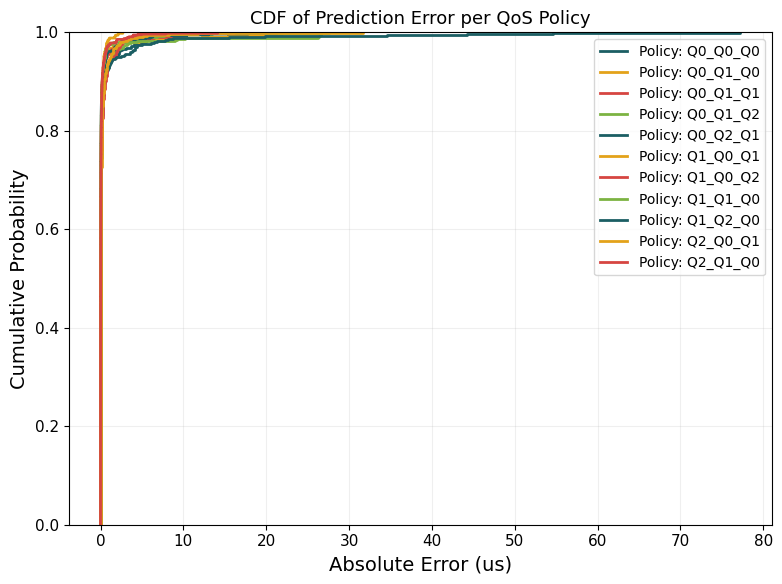

Policy: Q0_Q0_Q0 | R²: 0.989
Policy: Q0_Q1_Q0 | R²: 0.955
Policy: Q0_Q1_Q1 | R²: 0.987
Policy: Q0_Q1_Q2 | R²: 0.977
Policy: Q0_Q2_Q1 | R²: 0.974
Policy: Q1_Q0_Q1 | R²: 0.999
Policy: Q1_Q0_Q2 | R²: 0.991
Policy: Q1_Q1_Q0 | R²: 0.955
Policy: Q1_Q2_Q0 | R²: 0.897
Policy: Q2_Q0_Q1 | R²: 0.976
Policy: Q2_Q1_Q0 | R²: 0.995


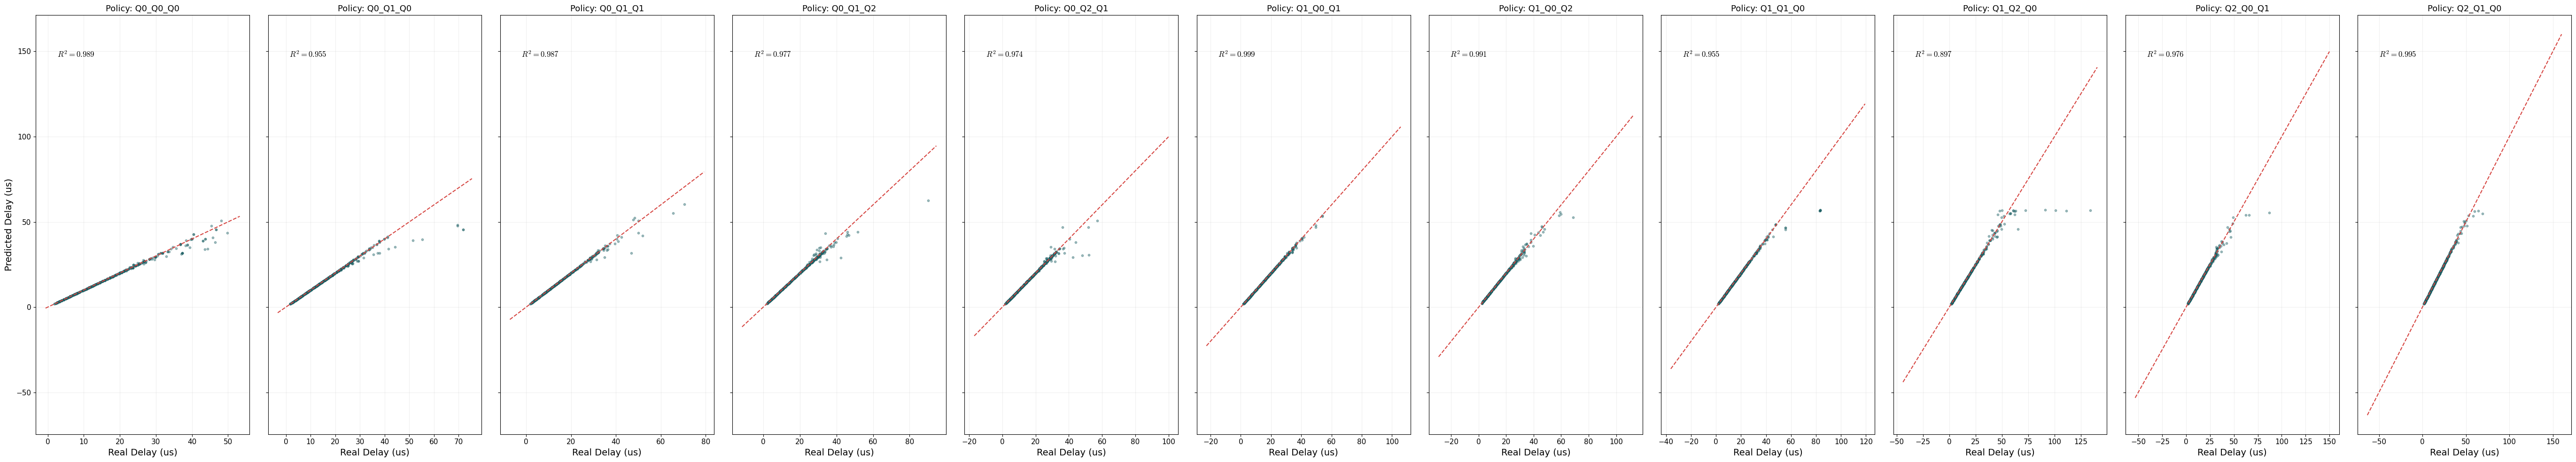

In [11]:
import seaborn as sns

# Configuración para estilo de publicación (Fuentes más grandes, líneas claras)
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 14, 'legend.fontsize': 10})

# ---------------------------------------------------------
# GRAFICA A: CDF DEL ERROR POR POLÍTICA
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
for i, pol in enumerate(df['policy'].unique()):
    sub = df[df['policy'] == pol]
    # Calculamos la CDF
    sns.ecdfplot(sub['err'], label=f'Policy: {pol}', linewidth=2)

plt.xlabel("Absolute Error (us)")
plt.ylabel("Cumulative Probability")
plt.title("CDF of Prediction Error per QoS Policy")
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# GRAFICA B: TARGET vs PREDICTION (REGRESIÓN MULTI-PANEL)
# ---------------------------------------------------------
policies = df['policy'].unique()
fig, axes = plt.subplots(1, len(policies), figsize=(5*len(policies), 10), sharey=True)

for i, pol in enumerate(policies):
    sub = df[df['policy'] == pol]
    ax = axes[i]
    
    # Scatter plot con densidad
    ax.scatter(sub['real'], sub['pred'], alpha=0.4, s=10, color=servicecolors[0])
    
    # Línea de referencia y=x
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, color=servicecolors[2], linestyle='--', label='Perfect Fit')
    
    # Calcular R² para el paper
    r2 = np.corrcoef(sub['real'], sub['pred'])[0,1]**2
    print(f"Policy: {pol} | R²: {r2:.3f}")
    ax.text(0.1, 0.9, f"$R^2 = {r2:.3f}$", transform=ax.transAxes, fontsize=12, fontweight='bold')
    
    ax.set_title(f"Policy: {pol}")
    ax.set_xlabel("Real Delay (us)")
    if i == 0: ax.set_ylabel("Predicted Delay (us)")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [14]:
import re
from sklearn.metrics import r2_score, mean_absolute_error

# ==========================================
# 1. FUNCIONES DE EXTRACCIÓN (Regex)
# ==========================================
def get_graph_type(s):
    # Extrae lo que hay entre 'graph_' y '_ALL' (ej: SPGraph, SPWRRGraph_10_90)
    m = re.search(r"graph_(.*?)_ALL", s)
    return m.group(1) if m else "Unknown"

def get_policy(s):
    # Extrae el mapeo de colas (ej: Q0_Q1_Q2)
    m = re.search(r"(Q\d+_Q\d+_Q\d+)", s)
    return m.group(1) if m else "UNK"

# ==========================================
# 2. APLICAR EXTRACCIÓN AL DATAFRAME
# ==========================================
# Asumiendo que 'df' es tu DataFrame con columnas ['scenario', 'real', 'pred']
df['scheduler'] = df['scenario'].apply(get_graph_type)
df['policy'] = df['scenario'].apply(get_policy)

# ==========================================
# 3. CÁLCULO DE MÉTRICAS CIENTÍFICAS
# ==========================================
def scientific_metrics(group):
    r = group['real']
    p = group['pred']
    return pd.Series({
        'R2_Score': r2_score(r, p),
        'MAPE_%': (np.abs(r - p) / r).mean() * 100,
        'MAE_us': mean_absolute_error(r, p),
        'Count': len(r)
    })

# --- TABLA A: RENDIMIENTO POR SCHEDULER ---
# Esto demuestra que la GNN entiende SP vs WRR
table_scheduler = df.groupby('scheduler').apply(scientific_metrics).reset_index()
table_scheduler = table_scheduler.sort_values(by='R2_Score', ascending=False)

# --- TABLA B: RENDIMIENTO POR POLÍTICA ---
# Esto demuestra que la GNN entiende el mapeo de flujos
table_policy = df.groupby('policy').apply(scientific_metrics).reset_index()
table_policy = table_policy.sort_values(by='R2_Score', ascending=False)

# ==========================================
# 4. VISUALIZACIÓN DE RESULTADOS
# ==========================================
print("\n" + "="*70)
print("   TABLE 1: PERFORMANCE BY SCHEDULER TYPE (SP vs WRR)")
print("="*70)
print(table_scheduler.round(4).to_string(index=False))

print("\n" + "="*70)
print("   TABLE 2: PERFORMANCE BY QoS MAPPING POLICY")
print("="*70)
print(table_policy.round(4).to_string(index=False))

# --- MÉTRICA GLOBAL FINAL PARA EL ABSTRACT DEL PAPER ---
global_r2 = r2_score(df['real'], df['pred'])
global_mape = (np.abs(df['real'] - df['pred']) / df['real']).mean() * 100
print(f"\n[!] RESULTADO GLOBAL: Mean R2 = {global_r2:.4f} | Mean MAPE = {global_mape:.2f}%")


   TABLE 1: PERFORMANCE BY SCHEDULER TYPE (SP vs WRR)
       scheduler  R2_Score  MAPE_%  MAE_us  Count
SPWRRGraph_40_60    0.9926  0.6861  0.2322  696.0
SPWRRGraph_30_70    0.9841  0.6517  0.2392  692.0
SPWRRGraph_60_40    0.9824  0.7128  0.2887  704.0
SPWRRGraph_90_10    0.9718  0.6273  0.2524  696.0
SPWRRGraph_50_50    0.9702  0.8403  0.3452  744.0
SPWRRGraph_70_30    0.9558  0.6985  0.2887  672.0
         SPGraph    0.9435  0.8959  0.3684  732.0
SPWRRGraph_10_90    0.8975  1.0078  0.5367  696.0

   TABLE 2: PERFORMANCE BY QoS MAPPING POLICY
  policy  R2_Score  MAPE_%  MAE_us  Count
Q1_Q0_Q1    0.9992  0.3547  0.0960  516.0
Q2_Q1_Q0    0.9943  0.4450  0.1599  556.0
Q1_Q0_Q2    0.9902  0.8463  0.2701  484.0
Q0_Q0_Q0    0.9876  0.9181  0.3095  480.0
Q0_Q1_Q1    0.9859  0.6138  0.2360  464.0
Q0_Q1_Q2    0.9760  0.9414  0.3308  508.0
Q2_Q0_Q1    0.9741  0.8556  0.3050  496.0
Q0_Q2_Q1    0.9737  0.7659  0.2589  592.0
Q0_Q1_Q0    0.9462  0.8631  0.3797  524.0
Q1_Q1_Q0    0.9428  0.7610  

/home/administrator/6gsenses/venv/lib/python3.7/site-packages/ipykernel_launcher.py:76: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.


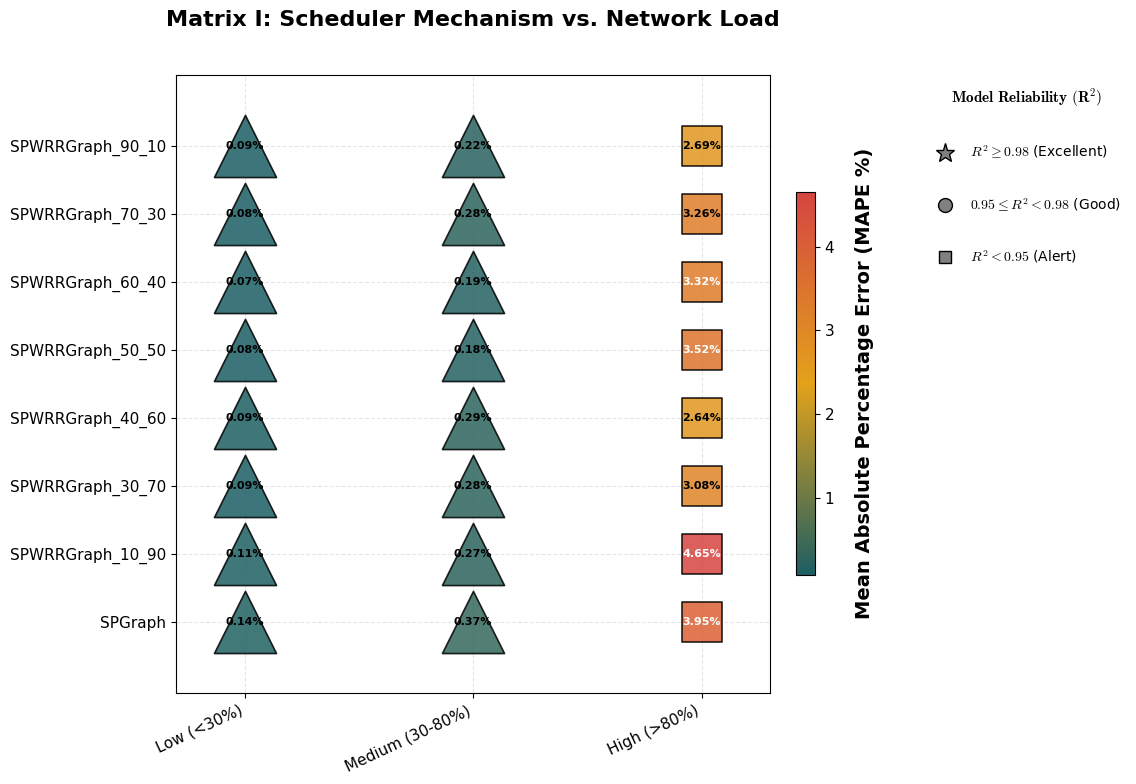

CSV 'matrix_data.csv' generado correctamente.


/home/administrator/6gsenses/venv/lib/python3.7/site-packages/ipykernel_launcher.py:76: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.


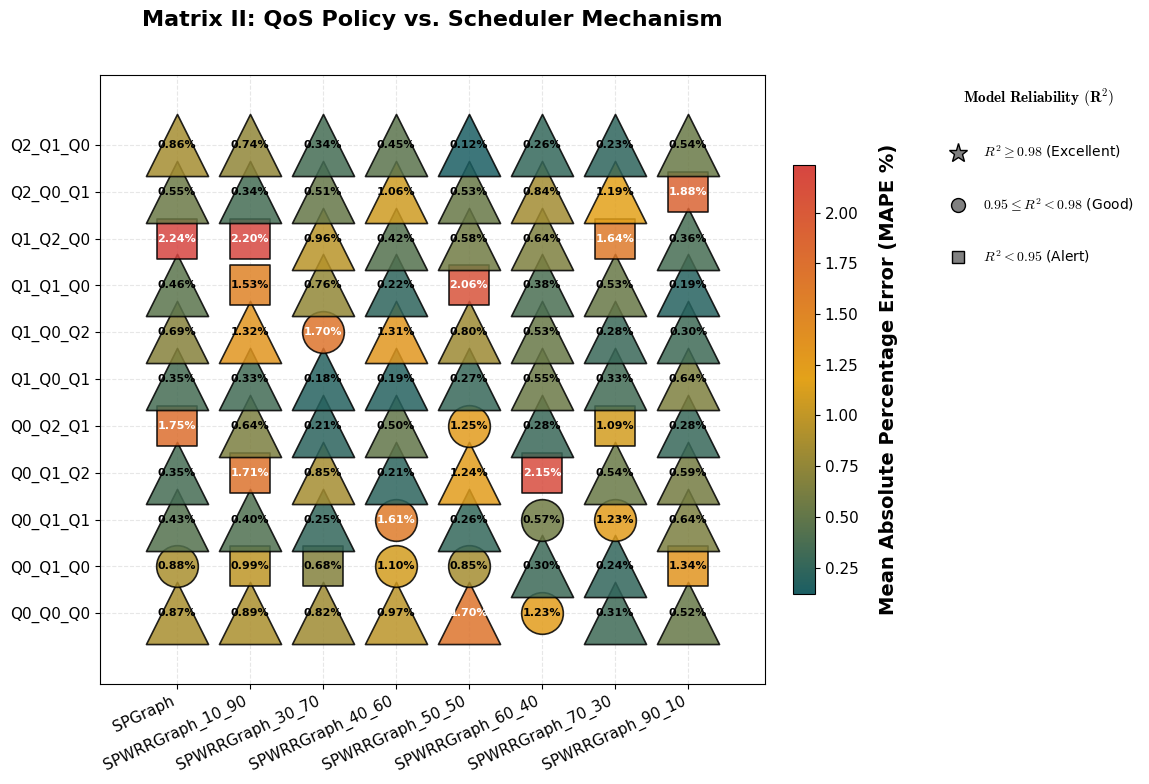

CSV 'matrix_data.csv' generado correctamente.


/home/administrator/6gsenses/venv/lib/python3.7/site-packages/ipykernel_launcher.py:76: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.


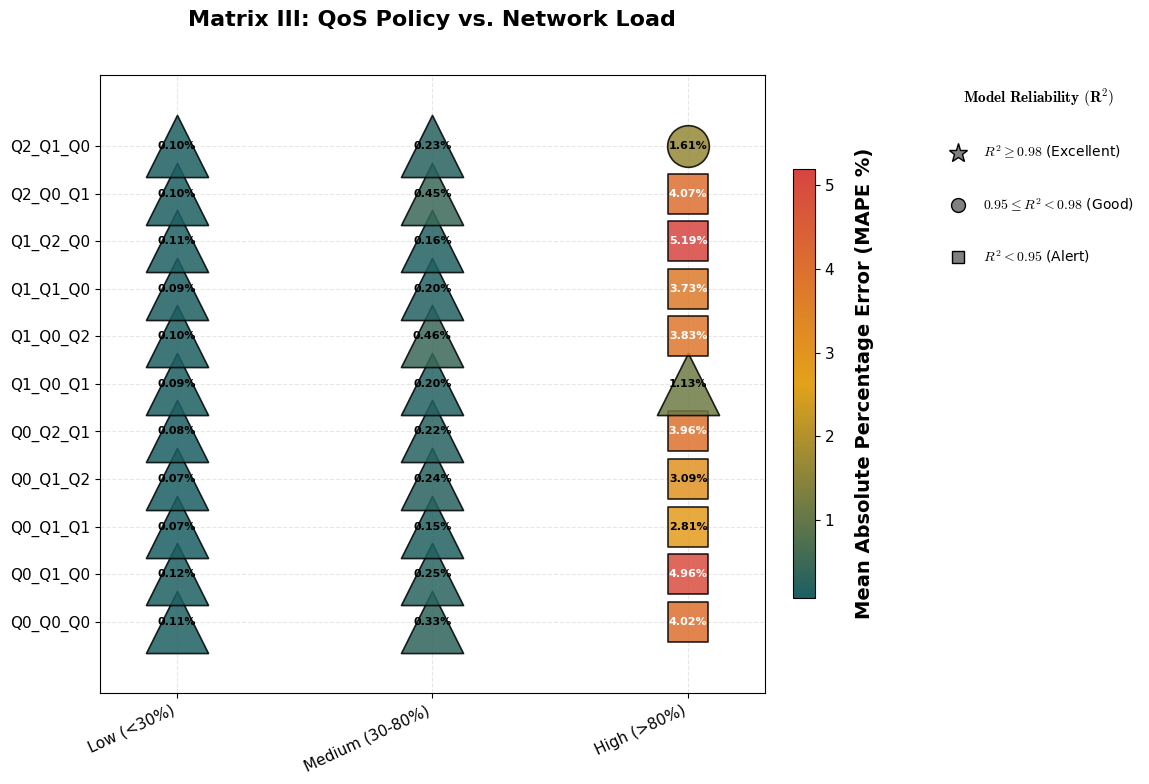

CSV 'matrix_data.csv' generado correctamente.


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.lines import Line2D
from sklearn.metrics import r2_score


def draw_paper_bubble_matrix(df_plot, x_col, y_col, title, x_order=None):
    # 1. Cálculo de métricas
    def get_stats(group):
        r, p = group['real'], group['pred']
        mape = np.mean(np.abs((r - p) / np.maximum(r, 1e-9))) * 100
        r2 = r2_score(r, p) if len(r) > 1 else 0
        return pd.Series({'MAPE': mape, 'R2': r2})

    stats = df_plot.groupby([x_col, y_col]).apply(get_stats).reset_index()
    
    # 2. Preparación de coordenadas
    x_labels = x_order if x_order else sorted(stats[x_col].unique())
    y_labels = sorted(stats[y_col].unique())
    x_map = {val: i for i, val in enumerate(x_labels)}
    y_map = {val: i for i, val in enumerate(y_labels)}
    
    # stats = stats[stats[x_col].isin(x_labels)].copy()
    #     # Dentro de tu función o después de calcular 'stats':
    # stats['symbol'] = np.where(stats['R2'] >= 0.98, 'hexagon', 
    #                 np.where(stats['R2'] >= 0.95, 'circle', 'square'))
    # stats.to_csv('matrix_data.csv', index=False)
    
 
    # 3. Estética de Color
    colors = ["#1b5e63", "#e3a21a", "#d64541"]
    custom_cmap = LinearSegmentedColormap.from_list("paper_map", colors)
    norm = Normalize(vmin=stats['MAPE'].min(), vmax=stats['MAPE'].max())

    fig, ax = plt.subplots(figsize=(12, 8))
    
    # 4. Renderizado punto por punto
    for i in range(len(stats)):
        row = stats.iloc[i]
        r2, mape = row['R2'], row['MAPE']
        x, y = x_map[row[x_col]], y_map[row[y_col]]
        
        if r2 >= 0.98:
            m, s = '^', 2000
        elif r2 >= 0.95:
            m, s = 'o', 900
        else:
            m, s = 's', 800
            
        facecolor = custom_cmap(norm(mape))
        ax.scatter(x, y, s=s, color=facecolor, marker=m, 
                   alpha=0.85, edgecolors="black", linewidth=1.2, zorder=3)
        
        text_color = 'white' if norm(mape) > 0.7 else 'black'
        ax.text(x, y, f"{mape:.2f}%", ha='center', va='center', 
                fontsize=8, fontweight='bold', color=text_color, zorder=4)

    # 5. Configuración de Ejes (CORRECCIÓN AQUÍ)
    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=25, ha="right")
    ax.set_yticks(range(len(y_labels)))
    ax.set_yticklabels(y_labels)
    ax.set_title(title, fontsize=16, fontweight='bold', pad=35)
    
    ax.grid(True, linestyle='--', alpha=0.3, zorder=0)
    
    # El método correcto es ax.margins(), no set_margins()
    ax.margins(0.15)
    
    # 6. Barra de Color
    sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=norm)
    # En versiones viejas de MPL, ScalarMappable necesita el array de datos
    sm.set_array([]) 
    cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
    cbar.set_label('Mean Absolute Percentage Error (MAPE %)', fontweight='bold', labelpad=15)

    # 7. Leyenda
    legend_elements = [
        Line2D([0], [0], marker='*', color='w', label=r'$R^2 \geq 0.98$ (Excellent)', 
               markerfacecolor='gray', markersize=14, markeredgecolor='black'),
        Line2D([0], [0], marker='o', color='w', label=r'$0.95 \leq R^2 < 0.98$ (Good)', 
               markerfacecolor='gray', markersize=10, markeredgecolor='black'),
        Line2D([0], [0], marker='s', color='w', label=r'$R^2 < 0.95$ (Alert)', 
               markerfacecolor='gray', markersize=9, markeredgecolor='black')
    ]
    
    ax.legend(handles=legend_elements, title=r"$\mathbf{Model\ Reliability\ (R^2)}$", 
              loc="upper left", bbox_to_anchor=(1.25, 1), frameon=False, 
              labelspacing=2.5, title_fontsize=11)

    plt.tight_layout()
    plt.show()
    
   
    # 4. Exportar asegurando comas y sin índice
    stats.to_csv('matrix_data.csv', index=False, sep=',')
    print("CSV 'matrix_data.csv' generado correctamente.")

# Ejecución
u_order = ["Low (<30%)", "Medium (30-80%)", "High (>80%)"]

# Matrix I: Scheduler vs Utilization
draw_paper_bubble_matrix(df, 'utilization', 'scheduler', 
                         "Matrix I: Scheduler Mechanism vs. Network Load", 
                         x_order=u_order)

# Matrix II: QoS Policy vs Scheduler
draw_paper_bubble_matrix(df, 'scheduler', 'policy', 
                         "Matrix II: QoS Policy vs. Scheduler Mechanism")

# Matrix III: QoS Policy vs Utilization
draw_paper_bubble_matrix(df, 'utilization', 'policy', 
                         "Matrix III: QoS Policy vs. Network Load", 
                         x_order=u_order)




/home/administrator/6gsenses/venv/lib/python3.7/site-packages/ipykernel_launcher.py:64: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.


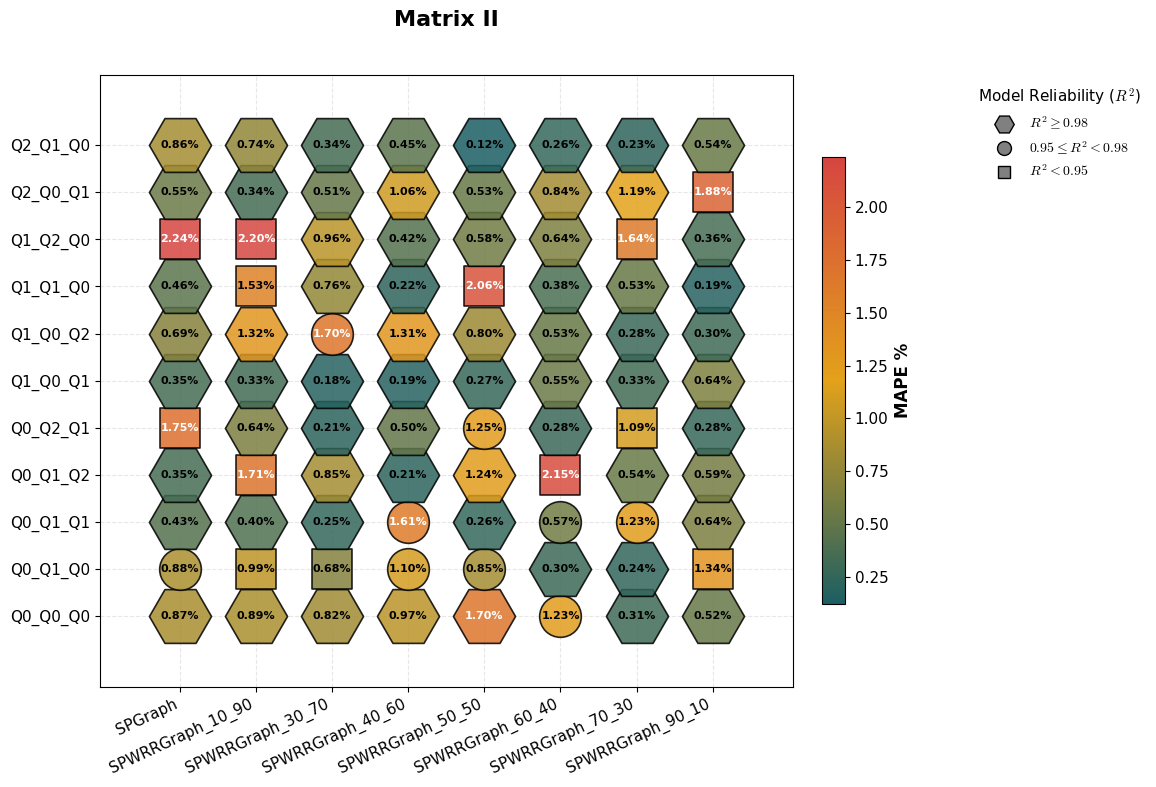

✅ CSV 'matrix_data.csv' generado correctamente para TikZ.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.lines import Line2D
from sklearn.metrics import r2_score

def draw_paper_bubble_matrix(df_plot, x_col, y_col, title, x_order=None, csv_name='matrix_data.csv'):
    # 1. Cálculo de métricas
    def get_stats(group):
        r, p = group['real'], group['pred']
        mape = np.mean(np.abs((r - p) / np.maximum(r, 1e-9))) * 100
        r2 = r2_score(r, p) if len(r) > 1 else 0
        return pd.Series({'MAPE': mape, 'R2': r2})

    stats = df_plot.groupby([x_col, y_col]).apply(get_stats).reset_index()
    
    # 2. Preparación de coordenadas
    x_labels = x_order if x_order else sorted(stats[x_col].unique())
    y_labels = sorted(stats[y_col].unique())
    x_map = {val: i for i, val in enumerate(x_labels)}
    y_map = {val: i for i, val in enumerate(y_labels)}
    
    # Filtrar solo lo que está en x_order si se provee
    stats = stats[stats[x_col].isin(x_labels)].copy()

    # 3. Estética de Color
    colors = ["#1b5e63", "#e3a21a", "#d64541"]
    custom_cmap = LinearSegmentedColormap.from_list("paper_map", colors)
    norm = Normalize(vmin=stats['MAPE'].min(), vmax=stats['MAPE'].max())

    fig, ax = plt.subplots(figsize=(12, 8))
    
    # 4. Renderizado
    for i in range(len(stats)):
        row = stats.iloc[i]
        r2, mape = row['R2'], row['MAPE']
        x, y = x_map[row[x_col]], y_map[row[y_col]]
        
        if r2 >= 0.98: m, s = 'H', 2000
        elif r2 >= 0.95: m, s = 'o', 900
        else: m, s = 's', 800
            
        facecolor = custom_cmap(norm(mape))
        ax.scatter(x, y, s=s, color=facecolor, marker=m, 
                   alpha=0.85, edgecolors="black", linewidth=1.2, zorder=3)
        
        text_color = 'white' if norm(mape) > 0.7 else 'black'
        ax.text(x, y, f"{mape:.2f}%", ha='center', va='center', 
                fontsize=8, fontweight='bold', color=text_color, zorder=4)

    # 5. Configuración de Ejes
    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=25, ha="right")
    ax.set_yticks(range(len(y_labels)))
    ax.set_yticklabels(y_labels)
    ax.set_title(title, fontsize=16, fontweight='bold', pad=35)
    ax.grid(True, linestyle='--', alpha=0.3, zorder=0)
    ax.margins(0.15)
    
    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=norm)
    sm.set_array([]) 
    cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
    cbar.set_label('MAPE %', fontweight='bold')

    # Leyenda
    legend_elements = [
        Line2D([0], [0], marker='H', color='w', label=r'$R^2 \geq 0.98$', 
               markerfacecolor='gray', markersize=14, markeredgecolor='black'),
        Line2D([0], [0], marker='o', color='w', label=r'$0.95 \leq R^2 < 0.98$', 
               markerfacecolor='gray', markersize=10, markeredgecolor='black'),
        Line2D([0], [0], marker='s', color='w', label=r'$R^2 < 0.95$', 
               markerfacecolor='gray', markersize=9, markeredgecolor='black')
    ]
    ax.legend(handles=legend_elements, title=r"Model Reliability ($R^2$)", 
              loc="upper left", bbox_to_anchor=(1.25, 1), frameon=False)

    plt.tight_layout()
    plt.show()
    
    # --- EXPORTACIÓN PARA TIKZ (Corregida) ---
    stats_tikz = stats.copy()
    stats_tikz.columns = stats_tikz.columns.str.strip()
    
    # Renombrar columnas dinámicamente para que el CSV sea estándar para TikZ
    # x_col -> x_coord, y_col -> y_coord
    stats_tikz = stats_tikz.rename(columns={x_col: 'x_var', y_col: 'y_var'})
    
    # Limpiar strings
    stats_tikz['x_var'] = stats_tikz['x_var'].astype(str).str.strip()
    stats_tikz['y_var'] = stats_tikz['y_var'].astype(str).str.strip()

    # Columna de símbolos
    stats_tikz['symbol'] = 'square'
    stats_tikz.loc[stats_tikz['R2'] >= 0.95, 'symbol'] = 'circle'
    stats_tikz.loc[stats_tikz['R2'] >= 0.98, 'symbol'] = 'hexagon'

    stats_tikz.to_csv(csv_name, index=False)
    print(f"CSV '{csv_name}' generado correctamente para TikZ.")

# Ejecución
u_order = ["Low (<30%)", "Medium (30-80%)", "High (>80%)"]
draw_paper_bubble_matrix(df, 'scheduler', 'policy', "Matrix II", csv_name='matrix_data.csv')

In [21]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score

def draw_paper_bubble_matrix(df_plot, x_col, y_col, title, x_order=None, prefix="data"):
    """
    Calcula métricas y genera 3 archivos CSV (triángulos, círculos, cuadrados)
    basados en los umbrales de R2 para usar en PGFPlots/LaTeX.
    """
    # 1. Cálculo de métricas (MAPE y R2)
    def get_stats(group):
        r, p = group['real'], group['pred']
        # Evitamos división por cero con 1e-9
        mape = np.mean(np.abs((r - p) / np.maximum(r, 1e-9))) * 100
        # R2 requiere al menos 2 puntos
        r2 = r2_score(r, p) if len(r) > 1 else 0
        return pd.Series({'MAPE': mape, 'R2': r2})

    stats = df_plot.groupby([x_col, y_col]).apply(get_stats).reset_index()
    
    # 2. Preparación de coordenadas para LaTeX (0, 1, 2...)
    x_labels = x_order if x_order else sorted(stats[x_col].unique())
    y_labels = sorted(stats[y_col].unique())
    
    x_map = {val: i for i, val in enumerate(x_labels)}
    y_map = {val: i for i, val in enumerate(y_labels)}
    
    stats['x'] = stats[x_col].map(x_map)
    stats['y'] = stats[y_col].map(y_map)
    
    # Limpiamos datos que no estén en el orden especificado
    stats = stats.dropna(subset=['x', 'y'])

    # 3. Formateo para exportación
    df_latex = stats[['x', 'y', 'MAPE', 'R2']].rename(columns={'MAPE': 'mape', 'R2': 'r2'})
    
    # --- GENERACIÓN DE LOS 3 ARCHIVOS CSV ---
    
    # Fichero 1: Triángulos (Excelentes: R2 >= 0.98)
    tri = df_latex[df_latex['r2'] >= 0.98]
    tri.to_csv(f'{prefix}_triangulos.csv', index=False)
    
    # Fichero 2: Círculos (Buenos: 0.95 <= R2 < 0.98)
    cir = df_latex[(df_latex['r2'] >= 0.95) & (df_latex['r2'] < 0.98)]
    cir.to_csv(f'{prefix}_circulos.csv', index=False)
    
    # Fichero 3: Cuadrados (Alertas: R2 < 0.95)
    cua = df_latex[df_latex['r2'] < 0.95]
    cua.to_csv(f'{prefix}_cuadrados.csv', index=False)

    print(f"\n>>> Archivos generados para: {title}")
    print(f"    [Prefix: {prefix}]")
    print(f"    - {prefix}_triangulos.csv: {len(tri)} puntos")
    print(f"    - {prefix}_circulos.csv:   {len(cir)} puntos")
    print(f"    - {prefix}_cuadrados.csv:  {len(cua)} puntos")

# ==========================================
# EJECUCIÓN PARA TUS 3 MATRICES
# ==========================================

# Orden para el eje X de utilización
u_order = ["Low (<30%)", "Medium (30-80%)", "High (>80%)"]

# Matrix I: Scheduler vs Utilization
draw_paper_bubble_matrix(df, 'utilization', 'scheduler', 
                         "Matrix I: Scheduler vs Load", 
                         x_order=u_order, 
                         prefix="m1")

# Matrix II: QoS Policy vs Scheduler
draw_paper_bubble_matrix(df, 'scheduler', 'policy', 
                         "Matrix II: QoS vs Scheduler", 
                         prefix="m2")

# Matrix III: QoS Policy vs Utilization
draw_paper_bubble_matrix(df, 'utilization', 'policy', 
                         "Matrix III: QoS vs Load", 
                         x_order=u_order, 
                         prefix="m3")


>>> Archivos generados para: Matrix I: Scheduler vs Load
    [Prefix: m1]
    - m1_triangulos.csv: 16 puntos
    - m1_circulos.csv:   0 puntos
    - m1_cuadrados.csv:  8 puntos

>>> Archivos generados para: Matrix II: QoS vs Scheduler
    [Prefix: m2]
    - m2_triangulos.csv: 66 puntos
    - m2_circulos.csv:   9 puntos
    - m2_cuadrados.csv:  13 puntos

>>> Archivos generados para: Matrix III: QoS vs Load
    [Prefix: m3]
    - m3_triangulos.csv: 23 puntos
    - m3_circulos.csv:   1 puntos
    - m3_cuadrados.csv:  9 puntos
